# 🔍 Vérification des Images Corrompues

Ce notebook identifie les images corrompues ou illisibles dans le dataset.

In [1]:
import pandas as pd
import numpy as np
import cv2
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Chemins
DATA_PATH = "../data/raw/data.parquet"
IMAGES_DIR = "../data/raw/images"

# Chargement des données
print("📂 Chargement du fichier parquet...")
df = pd.read_parquet(DATA_PATH)
print(f"✅ {len(df)} produits chargés")
print(f"📊 Colonnes disponibles: {df.columns.tolist()}")

📂 Chargement du fichier parquet...
✅ 74125 produits chargés
📊 Colonnes disponibles: ['product_id', 'cluster_id', 'country_name', 'title', 'description', 'category_level_1_name', 'category_level_2_name', 'category_level_3_name', 'brand_name', 'url', 'shade_name', 'image_filename']


In [2]:
def check_image_integrity(image_path):
    """
    Vérifie si une image peut être lue correctement.
    Retourne: (is_valid, error_message)
    """
    # Vérifier si le fichier existe
    if not os.path.exists(image_path):
        return False, "Fichier introuvable"
    
    # Vérifier si le fichier a une taille > 0
    if os.path.getsize(image_path) == 0:
        return False, "Fichier vide (0 bytes)"
    
    # Essayer de lire avec OpenCV
    try:
        img = cv2.imread(image_path)
        if img is None:
            return False, "Impossible de lire avec OpenCV"
        
        # Vérifier les dimensions
        h, w = img.shape[:2]
        if h == 0 or w == 0:
            return False, f"Dimensions invalides ({w}x{h})"
        
        return True, "OK"
    
    except Exception as e:
        return False, f"Erreur: {str(e)}"

# Test rapide
print("🧪 Test de la fonction sur quelques images...")

🧪 Test de la fonction sur quelques images...


In [3]:
# Vérifier toutes les images du dataset
print("🔍 Vérification de toutes les images...")
print(f"📁 Répertoire: {IMAGES_DIR}\n")

corrupted_images = []
valid_count = 0
missing_count = 0
error_types = {}

# Parcourir toutes les lignes du dataframe
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Vérification"):
    if pd.isna(row['image_filename']):
        continue
    
    image_path = os.path.join(IMAGES_DIR, str(row['image_filename']))
    is_valid, error_msg = check_image_integrity(image_path)
    
    if is_valid:
        valid_count += 1
    else:
        corrupted_images.append({
            'index': idx,
            'image_filename': row['image_filename'],
            'product_id': row.get('product_id', 'N/A'),
            'category_level_2_name': row.get('category_level_2_name', 'N/A'),
            'category_level_3_name': row.get('category_level_3_name', 'N/A'),
            'error': error_msg
        })
        
        # Compter les types d'erreurs
        error_types[error_msg] = error_types.get(error_msg, 0) + 1

print(f"\n✅ Images valides: {valid_count}")
print(f"❌ Images corrompues/introuvables: {len(corrupted_images)}")
print(f"📊 Taux de réussite: {valid_count / len(df) * 100:.2f}%")

🔍 Vérification de toutes les images...
📁 Répertoire: ../data/raw/images



Vérification: 100%|██████████| 74125/74125 [35:22<00:00, 34.92it/s]  


✅ Images valides: 71170
❌ Images corrompues/introuvables: 2955
📊 Taux de réussite: 96.01%


In [5]:
# Afficher les types d'erreurs
print("\n📋 Répartition des erreurs:")
print("-" * 50)
for error_type, count in sorted(error_types.items(), key=lambda x: x[1], reverse=True):
    print(f"  {error_type}: {count} images")

# Créer un DataFrame avec les images corrompues
if len(corrupted_images) > 0:
    df_corrupted = pd.DataFrame(corrupted_images)
    print(f"\n📄 Premières images corrompues:")
    print(df_corrupted.head(10))
else:
    print("\n🎉 Aucune image corrompue trouvée !")
    df_corrupted = pd.DataFrame()


📋 Répartition des erreurs:
--------------------------------------------------
  Fichier vide (0 bytes): 2955 images

📄 Premières images corrompues:
   index                                     image_filename  \
0    174  1c8553d78b2539a26f978b025a9ead0d047fe99ad1919c...   
1    175  ea3255f18dc8d9f10539681a327d8769c60c9b48c2de0c...   
2    176  84cd7b714fcc3649b5804581faf16c920a59239e6cb537...   
3    177  75d2cb805effe087e187bb91df9b3ab7176f2e31aa0dea...   
4    178  e27d994d21fd569c5bf9f357d72e6b994fa67a23ec9337...   
5    235  67200f12655b491d1f1a8f12f845a79919843517150d23...   
6    238  dbf1459a0c8ca6a11028f79d0b2f4c9ec072565e83e72b...   
7    239  bc9b8310d35e0dad7da00acb37661ae2219d49cd09a70a...   
8    754  6c2b99353331df8c1ecfe0a5ff325002df4d71009af6ff...   
9   1037  41f66ae86b0ed6a3fc937fb49a2e1435420efbd0a6ce7c...   

                                          product_id category_level_2_name  \
0  1c8553d78b2539a26f978b025a9ead0d047fe99ad1919c...                  Face   
1

In [6]:
# Sauvegarder la liste des images corrompues
if len(corrupted_images) > 0:
    output_file = "../data/processed/corrupted_images_report.csv"
    df_corrupted.to_csv(output_file, index=False)
    print(f"💾 Rapport sauvegardé: {output_file}")
    
    # Statistiques par catégorie
    if 'category_level_2_name' in df_corrupted.columns:
        print("\n📊 Images corrompues par catégorie (Level 2):")
        print(df_corrupted['category_level_2_name'].value_counts())
    
    if 'category_level_3_name' in df_corrupted.columns:
        print("\n📊 Images corrompues par catégorie (Level 3):")
        print(df_corrupted['category_level_3_name'].value_counts())

💾 Rapport sauvegardé: ../data/processed/corrupted_images_report.csv

📊 Images corrompues par catégorie (Level 2):
category_level_2_name
Face          858
Lip           743
Nail          675
Eye           454
Hair Color    225
Name: count, dtype: int64

📊 Images corrompues par catégorie (Level 3):
category_level_3_name
Lipstick           356
Nail Polish        356
Foundation         343
Lip Gloss          205
Permanent Color    152
Concealer          150
Eye Shadow         149
Eye Liner          123
Blush              121
Setting             99
Lip Liner           93
Eyebrow             90
Nail Adhesives      90
Lip Tint            89
Nail Base           77
Nail Extension      74
Nail Care           68
Bronzer             62
Mascara             55
Highlighter         53
Hair Makeup         45
Fake Lashes         37
Direct Dye          24
Primer              17
Polish Remover       9
BB Cream             8
CC Cream             3
Tone-on-Tone         3
Contour              2
Herbal Color 

### Extraction et Analyse des Produits Eye

Ce notebook prépare le dataset pour les produits de la catégorie Eye (Eye Shadow, Eye Liner, etc.)

In [7]:
# Filtrer uniquement les produits Eye
print("Filtrage des produits Eye...")

# Les catégories Eye incluent: Eye Shadow, Eye Liner, Eyebrow
df_eye = df[df['category_level_2_name']=="Eye"].copy()

print(f"✅ {len(df_eye)} produits Eye trouvés")
print(f"📊 Distribution par sous-catégorie:")
print(df_eye['category_level_3_name'].value_counts())

# Filtrer uniquement les images valides (pas corrompues)
if len(corrupted_images) > 0:
    corrupted_filenames = set([item['image_filename'] for item in corrupted_images])
    df_eye = df_eye[~df_eye['image_filename'].isin(corrupted_filenames)]
    print(f"🧹 Après retrait des images corrompues: {len(df_eye)} produits")

df_eye.head()

Filtrage des produits Eye...
✅ 13967 produits Eye trouvés
📊 Distribution par sous-catégorie:
category_level_3_name
Eye Shadow     4198
Eyebrow        3192
Eye Liner      3166
Mascara        1923
Fake Lashes    1488
Name: count, dtype: int64
🧹 Après retrait des images corrompues: 13513 produits


,product_id,cluster_id,country_name,title,description,category_level_1_name,category_level_2_name,category_level_3_name,brand_name,url,shade_name,image_filename
9568,29ced26caa924a41abde6d374371d34d7288f619c34a5e...,2049001,USA,MAYBELLINE Master Precise All Day Liquid Eyeli...,Attention! Class is in session! Master Precise...,MakeUp,Eye,Eye Liner,Maybelline New York,https://www.amazon.com/dp/B0CLBFRS2Y,COBALT,29ced26caa924a41abde6d374371d34d7288f619c34a5e...
9569,82bdf83be6fba9f187467c4d3bd103aad05a84f58fb757...,2049001,USA,Maybelline New York Eye Studio Master Precise ...,None,MakeUp,Eye,Eye Liner,Maybelline New York,https://www.amazon.com/Maybelline-New-York-Pre...,Black,82bdf83be6fba9f187467c4d3bd103aad05a84f58fb757...
9570,94e727722e4c798670b8f7b6c176bd375686a4b06deb5d...,2049001,USA,Maybelline Eyestudio Master Precise All Day Li...,Master the art of the winged eyeliner with the...,MakeUp,Eye,Eye Liner,Maybelline New York,https://www.target.com/p/maybelline-eyestudio-...,111 Forest Brown,94e727722e4c798670b8f7b6c176bd375686a4b06deb5d...
9571,772f6b44b750899c48f077ebe64372086aa5ab3568e9b4...,2381001,USA,Tarte Quick Stick Waterproof Shadow and Liner ...,Eyes in 30 seconds! tarte TM 's quick stick TM...,MakeUp,Eye,Eye Liner,Tarte,https://www.dermstore.com/tarte-quick-stick-wa...,Please select a shade,772f6b44b750899c48f077ebe64372086aa5ab3568e9b4...
9572,9a61dc7a056d3bacfb741e86a2a7508b55b4c97ac25005...,6175001,USA,Kiko MILANO - Ultimate Pen Long Wear Black Eye...,"Maximum line precision, high coverage and last...",MakeUp,Eye,Eye Liner,Kiko Milano,https://www.amazon.com/KIKO-Milano-Ultimate-Pe...,Green,9a61dc7a056d3bacfb741e86a2a7508b55b4c97ac25005...


In [8]:
# extraire avec chaque category level_3 des images représentatives
representative_images = {}
for category in df_eye['category_level_3_name'].unique():
    df_cat = df_eye[df_eye['category_level_3_name'] == category]
    if len(df_cat) > 0:
        representative_images[category] = df_cat.iloc[0]['image_filename']


In [9]:
# Extraction de la couleur dominante avec KMeans et filtrage HSV
from sklearn.cluster import KMeans
from collections import Counter

# On désactive les warnings de thread pour KMeans
os.environ["OMP_NUM_THREADS"] = "1"

def get_shade_and_centers(image_path, category_l3):
    """
    Extrait la couleur dominante et renvoie également tous les centres de clusters trouvés.
    Utilise un filtrage HSV pour isoler les couleurs pertinentes.
    Retourne: (best_rgb_list, all_centers_list_of_lists)
    """
    img = cv2.imread(image_path)
    # Important : retourner un tuple (None, None) pour maintenir la structure
    if img is None: return None, None
    
    # 1. Resize
    img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_AREA)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # 2. PARAMÈTRES - Ajustés pour les produits Eye
    s_min = 25 
    v_min = 60
    # Ajustement spécifique pour Eye Liner (comme Lip Liner, souvent plus saturés)
    if category_l3 == 'Eye Liner':
        s_min = 45 

    # 3. MASQUE - Filtrage des pixels colorés
    mask = cv2.inRange(hsv, (0, s_min, v_min), (180, 255, 250))
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    
    # 4. EXTRACTION des pixels valides
    valid_pixels = img_rgb[mask > 0]
    
    # Masque de secours si trop peu de pixels
    if len(valid_pixels) < 10:
        mask_rescue = cv2.inRange(hsv, (0, 10, 40), (180, 255, 250))
        valid_pixels = img_rgb[mask_rescue > 0]
        if len(valid_pixels) < 10:
            return None, None

    # 5. K-MEANS
    try:
        # Sous-échantillonnage si trop de pixels
        if len(valid_pixels) > 1000:
            indices = np.random.choice(len(valid_pixels), 1000, replace=False)
            pixels_to_cluster = valid_pixels[indices]
        else:
            pixels_to_cluster = valid_pixels

        kmeans = KMeans(n_clusters=3, n_init=3, random_state=42)
        kmeans.fit(pixels_to_cluster)
        centers = kmeans.cluster_centers_ # Ceci est un numpy array float
        
        # 6. SÉLECTION DU MEILLEUR (SATURATION)
        # On choisit la couleur la plus saturée comme couleur principale
        centers_hsv = cv2.cvtColor(np.uint8([centers]), cv2.COLOR_RGB2HSV)[0]
        best_idx = np.argmax(centers_hsv[:, 1])
        
        # Formatage pour la sortie
        best_rgb = centers[best_idx].astype(int).tolist()
        
        # On convertit TOUS les centres en liste d'entiers pour stockage facile (Parquet/JSON)
        all_centers = centers.astype(int).tolist()
        
        return best_rgb, all_centers
        
    except Exception as e:
        return None, None

# Test sur quelques images
print("🧪 Test sur 3 images...")
for idx, row in df_eye.head(3).iterrows():
    img_path = os.path.join(IMAGES_DIR, str(row['image_filename']))
    dominant, all_colors = get_shade_and_centers(img_path, row['category_level_3_name'])
    print(f"  {row['image_filename']}: {dominant}")

🧪 Test sur 3 images...
  29ced26caa924a41abde6d374371d34d7288f619c34a5e1d2bff6f3fb56317fd.jpeg: [44, 90, 188]
  82bdf83be6fba9f187467c4d3bd103aad05a84f58fb757aa3ec6a7beb11b232a.jpeg: [60, 54, 56]
  94e727722e4c798670b8f7b6c176bd375686a4b06deb5dc0bd3ee52dd75b1d34.jpeg: [72, 59, 51]


In [10]:
# 3️⃣ Appliquer l'extraction sur tous les produits Eye
print("🚀 Démarrage de l'extraction étendue (RGB + Centers avec filtrage HSV)...")

# On s'assure de travailler sur la copie
df_eye = df_eye.copy() 

tqdm.pandas()

# 1. On applique la fonction qui retourne un tuple
# On stocke temporairement dans une Series de tuples
temp_results = df_eye.progress_apply(
    lambda row: get_shade_and_centers(
        os.path.join(IMAGES_DIR, str(row['image_filename'])), 
        row['category_level_3_name']
    ), axis=1
)

# 2. On "dézippe" la Series de tuples en deux colonnes distinctes
# Si temp_results contient des (None, None), zip gère ça correctement
df_eye['rgb_extracted'], df_eye['kmeans_centers'] = zip(*temp_results)

# Retirer les lignes où l'extraction a échoué
df_eye = df_eye[df_eye['rgb_extracted'].notna()].copy()

# Statistiques de succès
success_count = len(df_eye)
print(f"✅ Extraction terminée : {success_count} produits avec couleurs extraites")

# Vérification visuelle rapide des premières lignes
print("\nExemple de données extraites :")
print(df_eye[['image_filename', 'category_level_3_name', 'rgb_extracted', 'kmeans_centers']].head())

🚀 Démarrage de l'extraction étendue (RGB + Centers avec filtrage HSV)...


  7%|▋         | 997/13513 [00:51<14:16, 14.61it/s]C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
100%|██████████| 13513/13513 [11:40<00:00, 19.29it/s]


✅ Extraction terminée : 13158 produits avec couleurs extraites

Exemple de données extraites :
                                         image_filename category_level_3_name  \
9568  29ced26caa924a41abde6d374371d34d7288f619c34a5e...             Eye Liner   
9569  82bdf83be6fba9f187467c4d3bd103aad05a84f58fb757...             Eye Liner   
9570  94e727722e4c798670b8f7b6c176bd375686a4b06deb5d...             Eye Liner   
9571  772f6b44b750899c48f077ebe64372086aa5ab3568e9b4...             Eye Liner   
9572  9a61dc7a056d3bacfb741e86a2a7508b55b4c97ac25005...             Eye Liner   

       rgb_extracted                                     kmeans_centers  
9568   [44, 90, 188]   [[147, 86, 198], [44, 90, 188], [153, 162, 205]]  
9569    [60, 54, 56]   [[60, 54, 56], [201, 182, 183], [121, 114, 117]]  
9570    [72, 59, 51]      [[87, 71, 64], [72, 59, 51], [123, 107, 100]]  
9571  [175, 111, 92]  [[197, 135, 113], [175, 111, 92], [211, 171, 1...  
9572    [33, 75, 67]       [[33, 75, 67], [90, 1

## Visualisation des Shades Extraites

Affichage d'exemples aléatoires avec les 3 couleurs candidates et la couleur choisie mise en évidence.

## 🔬 Analyse par Sous-Catégorie (category_level_3)

Visualisation d'exemples pour identifier si des ajustements de paramètres HSV sont nécessaires par catégorie.

In [11]:
# Afficher la distribution des sous-catégories Eye
print("📊 Distribution des produits Eye par category_level_3:")
print("=" * 60)
category_counts = df_eye['category_level_3_name'].value_counts()
for category, count in category_counts.items():
    percentage = (count / len(df_eye)) * 100
    print(f"  {category}: {count} produits ({percentage:.1f}%)")
print("=" * 60)

📊 Distribution des produits Eye par category_level_3:
  Eye Shadow: 4026 produits (30.6%)
  Eyebrow: 3019 produits (22.9%)
  Eye Liner: 2881 produits (21.9%)
  Mascara: 1808 produits (13.7%)
  Fake Lashes: 1424 produits (10.8%)


📊 Génération de la visualisation par catégorie...


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


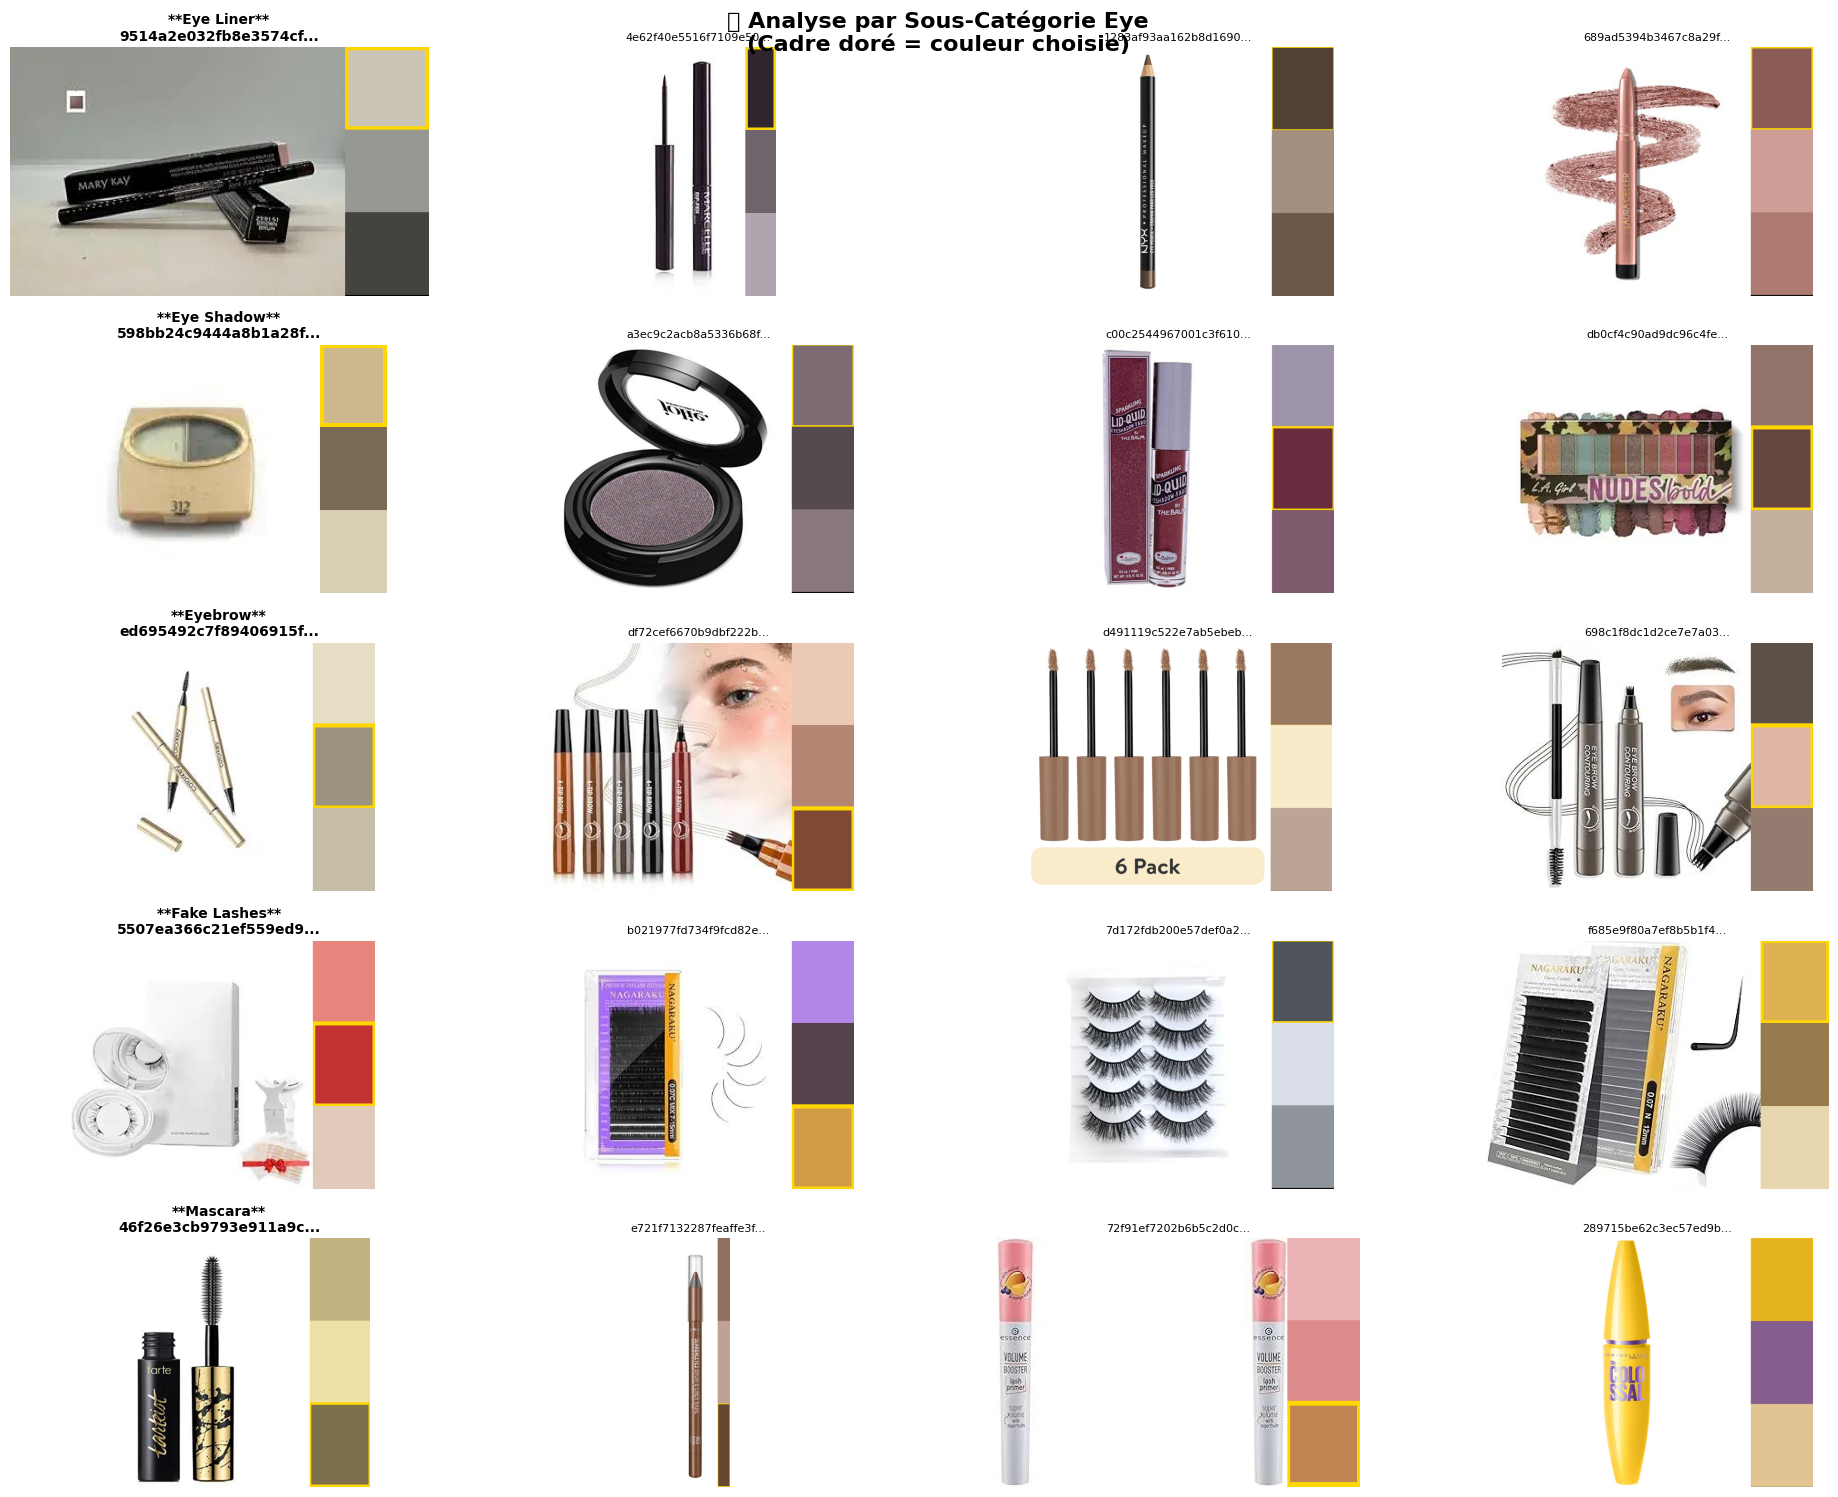

In [12]:
# Visualisation par catégorie : 4 exemples par category_level_3
def visualize_by_category(df, samples_per_category=4, figsize=(20, 15)):
    """
    Affiche des exemples d'extraction pour chaque sous-catégorie Eye.
    Permet d'identifier visuellement si des ajustements de paramètres sont nécessaires.
    """
    categories = df['category_level_3_name'].unique()
    n_categories = len(categories)
    
    fig, axes = plt.subplots(n_categories, samples_per_category, figsize=figsize)
    if n_categories == 1:
        axes = axes.reshape(1, -1)
    
    for cat_idx, category in enumerate(sorted(categories)):
        # Filtrer par catégorie
        df_cat = df[df['category_level_3_name'] == category]
        
        # Sélectionner aléatoirement des échantillons
        samples = df_cat.sample(n=min(samples_per_category, len(df_cat)))
        
        for sample_idx, (idx, row) in enumerate(samples.iterrows()):
            ax = axes[cat_idx, sample_idx] if n_categories > 1 else axes[sample_idx]
            
            # Charger l'image
            img_path = os.path.join(IMAGES_DIR, str(row['image_filename']))
            img = cv2.imread(img_path)
            
            if img is None:
                ax.text(0.5, 0.5, 'Image\nindisponible', ha='center', va='center')
                ax.axis('off')
                continue
            
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Créer une visualisation combinée : image + couleurs extraites
            h, w = img_rgb.shape[:2]
            
            # Créer une bande de couleurs à droite
            centers = row['kmeans_centers']
            chosen_color = row['rgb_extracted']
            
            if centers and len(centers) > 0:
                # Bande de couleurs (1/4 de la largeur)
                color_width = w // 4
                color_band = np.zeros((h, color_width, 3), dtype=np.uint8)
                color_h = h // len(centers)
                
                for i, color in enumerate(centers):
                    y_start = i * color_h
                    y_end = min((i + 1) * color_h, h)
                    color_band[y_start:y_end, :] = color
                    
                    # Marquer la couleur choisie
                    if color == chosen_color:
                        # Ajouter un cadre doré
                        cv2.rectangle(color_band, (0, y_start), (color_width-1, y_end-1), 
                                    (255, 215, 0), 3)
                
                # Combiner image et bande de couleurs
                combined = np.hstack([img_rgb, color_band])
            else:
                combined = img_rgb
            
            ax.imshow(combined)
            ax.axis('off')
            
            # Titre avec info
            if sample_idx == 0:
                title = f"**{category}**\n{row['image_filename'][:20]}..."
                ax.set_title(title, fontsize=10, fontweight='bold', pad=5)
            else:
                title = f"{row['image_filename'][:20]}..."
                ax.set_title(title, fontsize=8, pad=5)
    
    plt.tight_layout()
    plt.suptitle('🔬 Analyse par Sous-Catégorie Eye\n(Cadre doré = couleur choisie)', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.subplots_adjust(top=0.97)
    plt.show()

print("📊 Génération de la visualisation par catégorie...")
visualize_by_category(df_eye, samples_per_category=4)

📊 Génération de 6 exemples aléatoires...


C:\Users\hp\AppData\Local\Temp\ipykernel_24028\1370961558.py:69: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


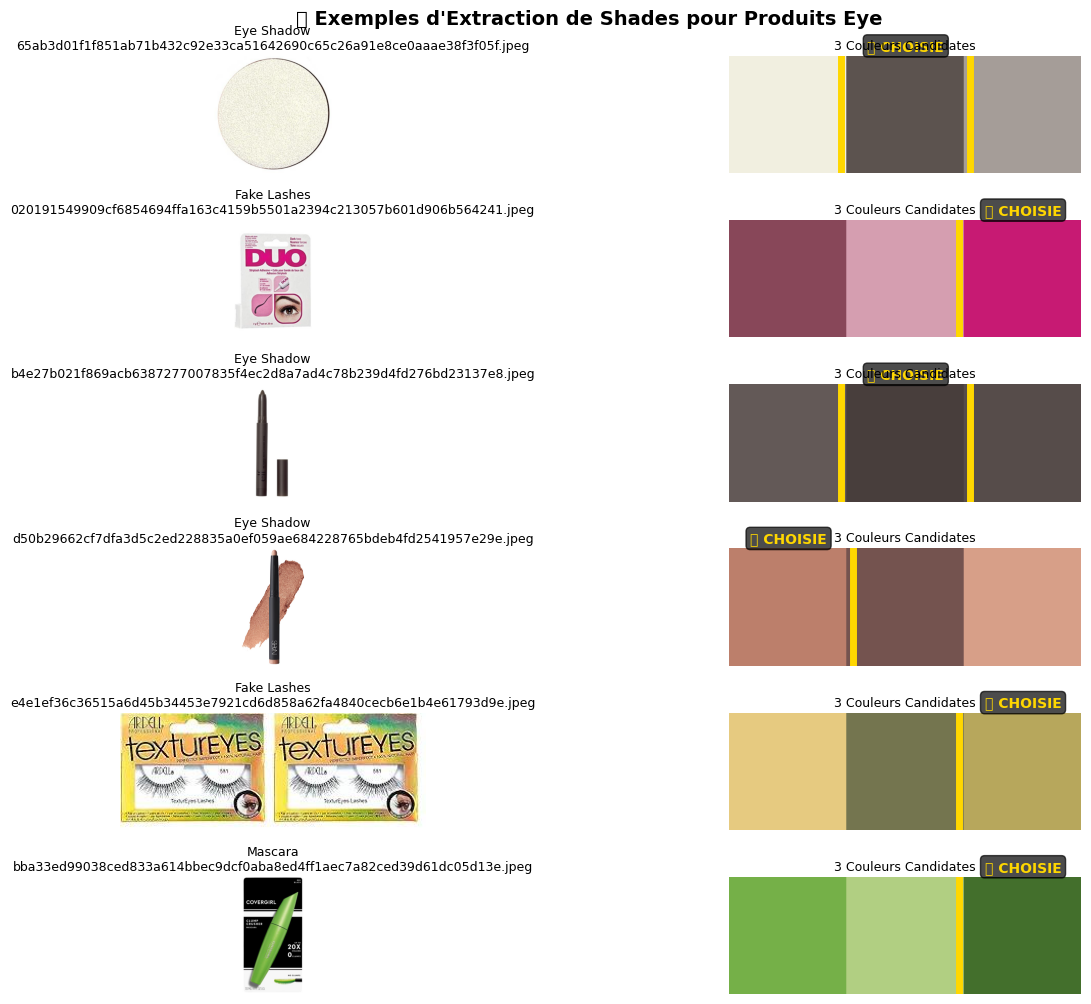

In [13]:
def visualize_shade_extraction(df, n_samples=6, figsize=(15, 10)):
    """
    Affiche n_samples exemples aléatoires avec:
    - L'image du produit
    - Les 3 couleurs candidates
    - La couleur choisie (rgb_extracted) mise en évidence avec un cadre
    """
    # Sélection aléatoire d'exemples
    samples = df.sample(n=min(n_samples, len(df)))
    
    # Configuration de la figure
    fig, axes = plt.subplots(n_samples, 2, figsize=figsize)
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, (idx, row) in enumerate(samples.iterrows()):
        # Charger l'image
        img_path = os.path.join(IMAGES_DIR, str(row['image_filename']))
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Afficher l'image du produit
        axes[i, 0].imshow(img_rgb)
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f"{row['category_level_3_name']}\n{row['image_filename']}", 
                             fontsize=9, pad=5)
        
        # Préparer les couleurs
        centers = row['kmeans_centers']
        chosen_color = row['rgb_extracted']
        
        # Créer une image avec les 3 couleurs candidates
        color_display = np.zeros((100, 300, 3), dtype=np.uint8)
        
        for j, color in enumerate(centers):
            # Dessiner chaque couleur (100x100 px)
            color_display[:, j*100:(j+1)*100] = color
        
        # Afficher les couleurs
        axes[i, 1].imshow(color_display)
        axes[i, 1].axis('off')
        axes[i, 1].set_title("3 Couleurs Candidates", fontsize=9, pad=5)
        
        # Trouver quelle couleur est la couleur choisie
        chosen_idx = None
        for j, color in enumerate(centers):
            if color == chosen_color:
                chosen_idx = j
                break
        
        # Ajouter un cadre autour de la couleur choisie
        if chosen_idx is not None:
            rect = patches.Rectangle(
                (chosen_idx * 100 - 5, -5), 110, 110,
                linewidth=5, edgecolor='gold', facecolor='none'
            )
            axes[i, 1].add_patch(rect)
            
            # Ajouter un label "CHOISIE"
            axes[i, 1].text(
                chosen_idx * 100 + 50, -15, '⭐ CHOISIE',
                ha='center', va='top', fontsize=10, 
                fontweight='bold', color='gold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
            )
    
    plt.tight_layout()
    plt.suptitle('🎨 Exemples d\'Extraction de Shades pour Produits Eye', 
                 fontsize=14, fontweight='bold', y=1.0)
    plt.show()

# Lancer la visualisation
print("📊 Génération de 6 exemples aléatoires...")
visualize_shade_extraction(df_eye, n_samples=6)

In [14]:
# 4️⃣ Sauvegarder le dataset complet
output_file = "../data/processed/eye_products_final_colors_full.parquet"
df_eye.to_parquet(output_file, index=False)
print(f"💾 Dataset sauvegardé : {output_file}")
print(f"📊 {len(df_eye)} produits Eye avec couleurs extraites")
print(f"📁 Colonnes: {df_eye.columns.tolist()}")

💾 Dataset sauvegardé : ../data/processed/eye_products_final_colors_full.parquet
📊 13158 produits Eye avec couleurs extraites
📁 Colonnes: ['product_id', 'cluster_id', 'country_name', 'title', 'description', 'category_level_1_name', 'category_level_2_name', 'category_level_3_name', 'brand_name', 'url', 'shade_name', 'image_filename', 'rgb_extracted', 'kmeans_centers']


### Clustering des Shades Eye

Maintenant que nous avons extrait les couleurs de chaque produit, nous allons **regrouper les produits similaires** en clusters basés sur leur couleur.

🎨 Données préparées: 13158 produits avec couleurs RGB
📐 Shape: (13158, 3)

🔍 Calcul des métriques pour différents nombres de clusters...
  K=5: Inertia=26332644, Silhouette=0.338
  K=6: Inertia=22698014, Silhouette=0.340
  K=7: Inertia=19680252, Silhouette=0.350
  K=8: Inertia=17729494, Silhouette=0.316
  K=9: Inertia=16337721, Silhouette=0.321
  K=10: Inertia=15270460, Silhouette=0.295
  K=11: Inertia=14304219, Silhouette=0.301
  K=12: Inertia=13417473, Silhouette=0.305
  K=13: Inertia=12680872, Silhouette=0.310
  K=14: Inertia=12020012, Silhouette=0.292
  K=15: Inertia=11485955, Silhouette=0.291
  K=16: Inertia=11066350, Silhouette=0.283
  K=17: Inertia=10583314, Silhouette=0.302
  K=18: Inertia=10209704, Silhouette=0.298
  K=19: Inertia=9810713, Silhouette=0.289
  K=20: Inertia=9511854, Silhouette=0.287


C:\Users\hp\AppData\Local\Temp\ipykernel_24028\2405768952.py:41: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_24028\2405768952.py:41: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


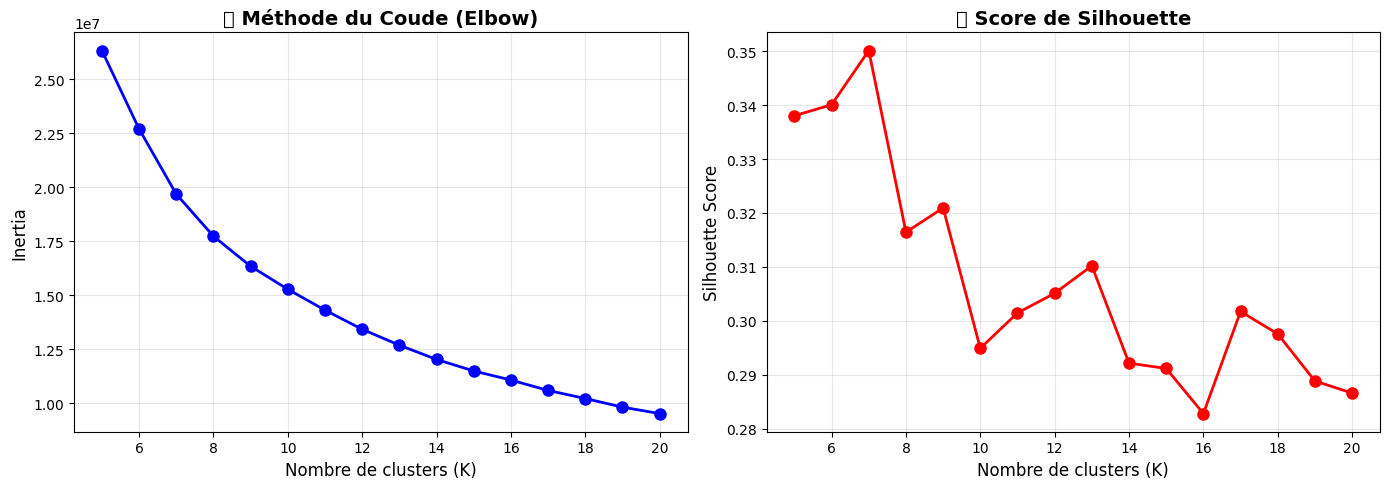


💡 K optimal sur RGB: 7 clusters (silhouette: 0.350)

🔄 Conversion des couleurs RGB → HSV pour clustering optimisé...
✅ Clustering avec HSV et K=7


In [15]:
#  Déterminer le nombre optimal de clusters
from sklearn.metrics import silhouette_score

# Préparer les données pour le clustering
X = np.array(df_eye['rgb_extracted'].tolist())

print(f" Données préparées: {len(X)} produits avec couleurs RGB")
print(f" Shape: {X.shape}")

# Tester différents nombres de clusters
K_range = range(5, 21)
inertias = []
silhouette_scores = []

print("\n Calcul des métriques pour différents nombres de clusters...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"  K={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={score:.3f}")

# Visualiser les métriques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title(' Méthode du Coude (Elbow)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title(' Score de Silhouette', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Recommandation basée sur RGB brut
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n K optimal sur RGB: {best_k} clusters (silhouette: {max(silhouette_scores):.3f})")

# AMÉLIORATION: Conversion en HSV pour un meilleur clustering
print("\n Conversion des couleurs RGB → HSV pour clustering optimisé...")
X_hsv = []
for rgb in X:
    rgb_norm = rgb.reshape(1, 1, 3).astype(np.uint8)
    hsv = cv2.cvtColor(rgb_norm, cv2.COLOR_RGB2HSV)[0, 0]
    X_hsv.append(hsv)
X_hsv = np.array(X_hsv)

n_clusters = best_k
print(f" Clustering avec HSV et K={n_clusters}")

In [16]:
#  Appliquer le clustering final avec HSV
print(f" Application du KMeans avec espace couleur HSV...")
print(f" K={n_clusters} clusters")

# Clustering sur les couleurs HSV
kmeans_final = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
df_eye['cluster_id'] = kmeans_final.fit_predict(X_hsv)

# Calculer les centres en HSV puis les convertir en RGB pour visualisation
cluster_centers_hsv = kmeans_final.cluster_centers_.astype(int)
cluster_centers = []

for center_hsv in cluster_centers_hsv:
    hsv_array = np.uint8([[center_hsv]])
    rgb_array = cv2.cvtColor(hsv_array, cv2.COLOR_HSV2RGB)[0, 0]
    cluster_centers.append(rgb_array)

cluster_centers = np.array(cluster_centers)
print(" Conversion HSV → RGB pour visualisation")

print(f" Clustering terminé!")
print(f" {n_clusters} clusters créés")
print(f"\n Distribution des produits par cluster:")
print(df_eye['cluster_id'].value_counts().sort_index())

# Afficher les couleurs moyennes par cluster
print(f"\n Couleurs moyennes par cluster:")
for i, center in enumerate(cluster_centers):
    count = len(df_eye[df_eye['cluster_id'] == i])
    print(f"  Cluster {i}: RGB{tuple(center)} - {count} produits")

🚀 Application du KMeans avec espace couleur HSV...
   K=7 clusters
   ✅ Conversion HSV → RGB pour visualisation
✅ Clustering terminé!
📊 7 clusters créés

📈 Distribution des produits par cluster:
cluster_id
0    3089
1    1776
2    2419
3    1923
4    1575
5    1188
6    1188
Name: count, dtype: int64

🎨 Couleurs moyennes par cluster:
  Cluster 0: RGB(np.uint8(112), np.uint8(78), np.uint8(58)) - 3089 produits
  Cluster 1: RGB(np.uint8(69), np.uint8(62), np.uint8(79)) - 1776 produits
  Cluster 2: RGB(np.uint8(187), np.uint8(156), np.uint8(132)) - 2419 produits
  Cluster 3: RGB(np.uint8(91), np.uint8(79), np.uint8(71)) - 1923 produits
  Cluster 4: RGB(np.uint8(87), np.uint8(37), np.uint8(151)) - 1575 produits
  Cluster 5: RGB(np.uint8(204), np.uint8(142), np.uint8(61)) - 1188 produits
  Cluster 6: RGB(np.uint8(169), np.uint8(119), np.uint8(175)) - 1188 produits


📊 Génération de la visualisation des clusters...


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


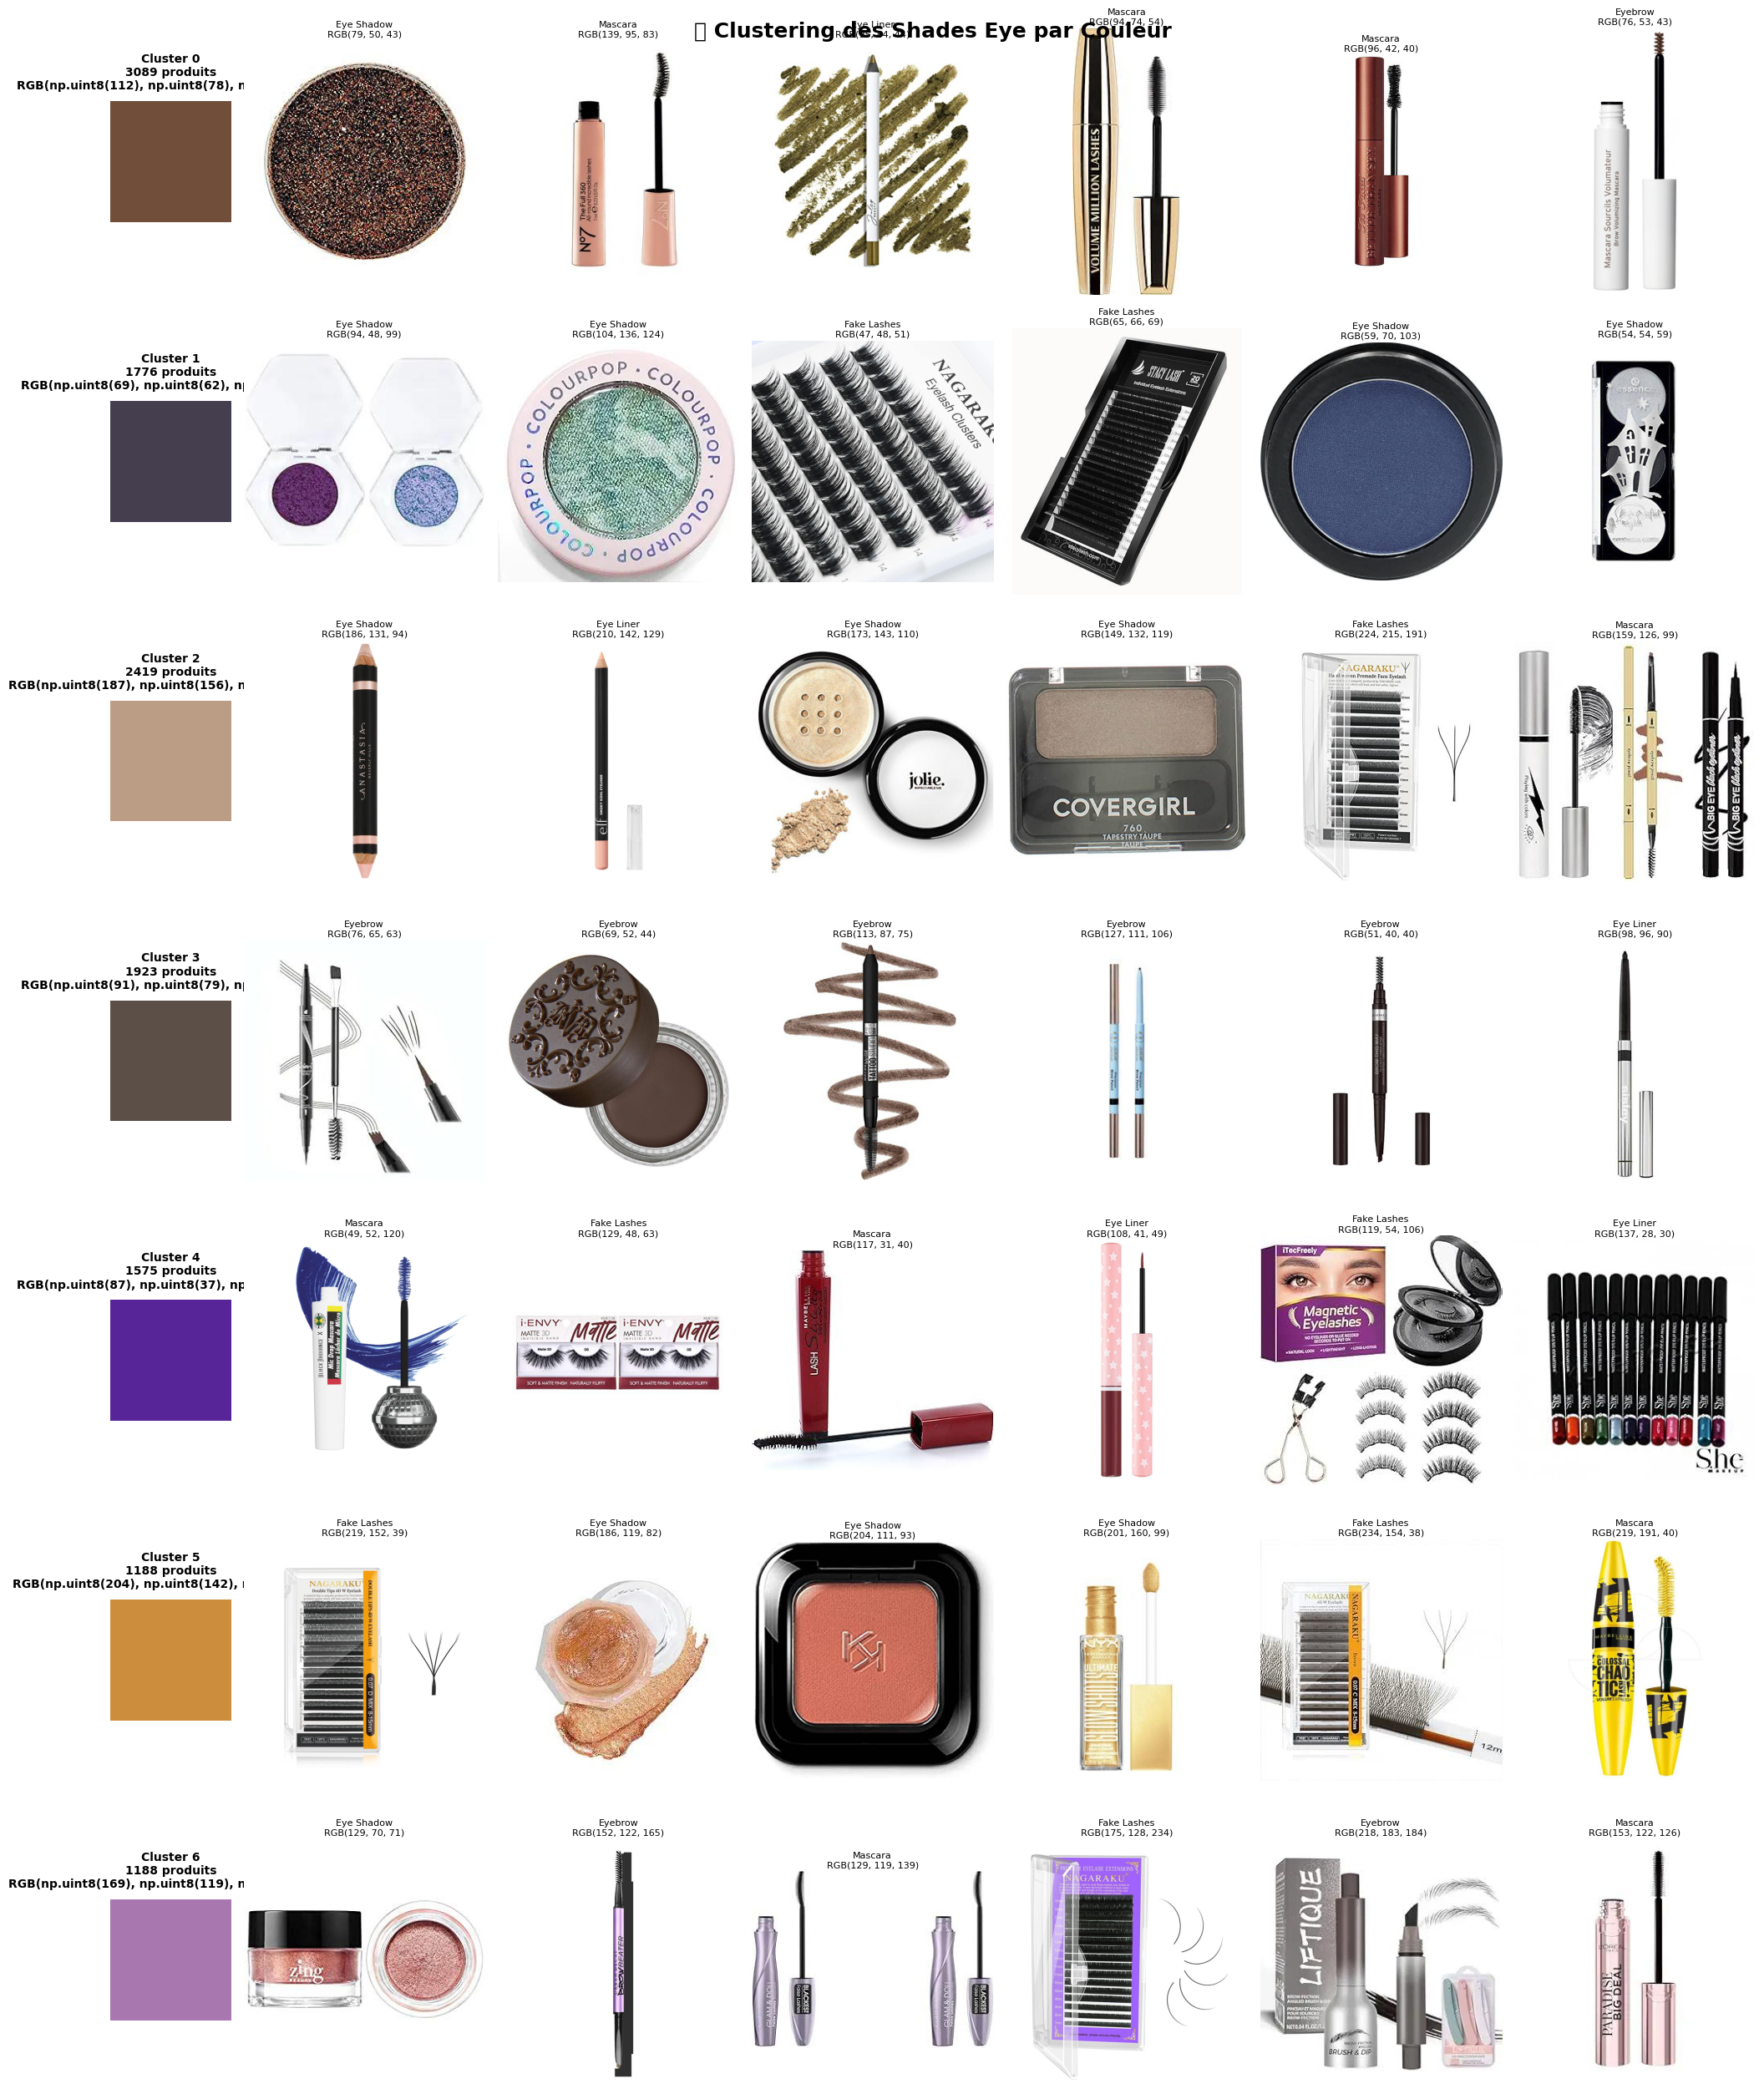

In [17]:
# 🎨 Visualisation des clusters de shades
def visualize_clusters(df, cluster_centers, samples_per_cluster=6, figsize=(20, 25)):
    """
    Visualise les produits regroupés par cluster avec leurs couleurs.
    """
    n_clusters = len(cluster_centers)
    
    fig, axes = plt.subplots(n_clusters, samples_per_cluster + 1, 
                             figsize=figsize,
                             gridspec_kw={'width_ratios': [1] + [2]*samples_per_cluster})
    
    for cluster_id in range(n_clusters):
        # Filtrer les produits du cluster
        df_cluster = df[df['cluster_id'] == cluster_id]
        cluster_color = cluster_centers[cluster_id]
        
        # Première colonne: couleur moyenne du cluster
        ax_color = axes[cluster_id, 0]
        color_patch = np.ones((100, 100, 3), dtype=np.uint8) * cluster_color
        ax_color.imshow(color_patch)
        ax_color.axis('off')
        ax_color.set_title(f"Cluster {cluster_id}\n{len(df_cluster)} produits\nRGB{tuple(cluster_color)}", 
                          fontsize=10, fontweight='bold', pad=10)
        
        # Colonnes suivantes: exemples de produits
        samples = df_cluster.sample(n=min(samples_per_cluster, len(df_cluster)))
        
        for i, (idx, row) in enumerate(samples.iterrows()):
            ax = axes[cluster_id, i + 1]
            
            # Charger l'image
            img_path = os.path.join(IMAGES_DIR, str(row['image_filename']))
            img = cv2.imread(img_path)
            
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img_rgb)
                ax.set_title(f"{row['category_level_3_name']}\nRGB{tuple(row['rgb_extracted'])}", 
                           fontsize=8, pad=3)
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            
            ax.axis('off')
        
        # Remplir les colonnes vides si moins d'échantillons
        for i in range(len(samples), samples_per_cluster):
            axes[cluster_id, i + 1].axis('off')
    
    plt.tight_layout()
    plt.suptitle('🎨 Clustering des Shades Eye par Couleur', 
                 fontsize=18, fontweight='bold', y=0.998)
    plt.subplots_adjust(top=0.995)
    plt.show()

print("📊 Génération de la visualisation des clusters...")
visualize_clusters(df_eye, cluster_centers, samples_per_cluster=6)

In [18]:
# 📊 Analyse détaillée par cluster et catégorie
print("📊 Répartition des sous-catégories par cluster:\n")
print("=" * 80)

for cluster_id in sorted(df_eye['cluster_id'].unique()):
    df_cluster = df_eye[df_eye['cluster_id'] == cluster_id]
    print(f"\n🎨 Cluster {cluster_id} ({len(df_cluster)} produits) - RGB{tuple(cluster_centers[cluster_id])}")
    print("-" * 80)
    
    # Distribution par category_level_3
    cat_dist = df_cluster['category_level_3_name'].value_counts()
    for cat, count in cat_dist.items():
        percentage = (count / len(df_cluster)) * 100
        print(f"  {cat}: {count} ({percentage:.1f}%)")

print("\n" + "=" * 80)

📊 Répartition des sous-catégories par cluster:


🎨 Cluster 0 (3089 produits) - RGB(np.uint8(112), np.uint8(78), np.uint8(58))
--------------------------------------------------------------------------------
  Eye Shadow: 1074 (34.8%)
  Eyebrow: 981 (31.8%)
  Eye Liner: 581 (18.8%)
  Mascara: 241 (7.8%)
  Fake Lashes: 212 (6.9%)

🎨 Cluster 1 (1776 produits) - RGB(np.uint8(69), np.uint8(62), np.uint8(79))
--------------------------------------------------------------------------------
  Eye Liner: 653 (36.8%)
  Eye Shadow: 441 (24.8%)
  Mascara: 289 (16.3%)
  Eyebrow: 247 (13.9%)
  Fake Lashes: 146 (8.2%)

🎨 Cluster 2 (2419 produits) - RGB(np.uint8(187), np.uint8(156), np.uint8(132))
--------------------------------------------------------------------------------
  Eye Shadow: 1007 (41.6%)
  Eyebrow: 540 (22.3%)
  Eye Liner: 414 (17.1%)
  Mascara: 236 (9.8%)
  Fake Lashes: 222 (9.2%)

🎨 Cluster 3 (1923 produits) - RGB(np.uint8(91), np.uint8(79), np.uint8(71))
----------------------------

In [19]:
# 💾 Sauvegarder le dataset final avec clusters
output_file_clustered = "../data/processed/eye_products_clustered.parquet"
df_eye.to_parquet(output_file_clustered, index=False)

print(f"💾 Dataset avec clusters sauvegardé: {output_file_clustered}")
print(f"📊 {len(df_eye)} produits Eye")
print(f"🎨 {n_clusters} clusters de couleurs")
print(f"📁 Colonnes: {df_eye.columns.tolist()}")

# Statistiques finales
print("\n" + "=" * 60)
print("✅ RÉSUMÉ FINAL")
print("=" * 60)
print(f"Total produits Eye: {len(df_eye)}")
print(f"Nombre de clusters: {n_clusters}")
print(f"Catégories: {df_eye['category_level_3_name'].unique().tolist()}")
print(f"Fichier sauvegardé: {output_file_clustered}")
print("=" * 60)

💾 Dataset avec clusters sauvegardé: ../data/processed/eye_products_clustered.parquet
📊 13158 produits Eye
🎨 7 clusters de couleurs
📁 Colonnes: ['product_id', 'cluster_id', 'country_name', 'title', 'description', 'category_level_1_name', 'category_level_2_name', 'category_level_3_name', 'brand_name', 'url', 'shade_name', 'image_filename', 'rgb_extracted', 'kmeans_centers']

✅ RÉSUMÉ FINAL
Total produits Eye: 13158
Nombre de clusters: 7
Catégories: ['Eye Liner', 'Eye Shadow', 'Eyebrow', 'Fake Lashes', 'Mascara']
Fichier sauvegardé: ../data/processed/eye_products_clustered.parquet


### Outil de Labeling Manuel pour Eye

Cet outil permet de valider manuellement la couleur extraite pour chaque produit Eye.

In [27]:
# --- CONFIGURATION DE L'OUTIL DE LABELING ---
PARQUET_FILE = "../data/processed/eye_products_final_colors_full.parquet"
OUTPUT_FILE = "../data/processed/eye_products_labeled.parquet"
IMAGE_DIR = "../data/raw/images"

def create_display_image(img_path, candidates, current_choice_idx=None):
    """Crée une image composite : Photo à gauche, Candidats à droite."""
    # 1. Charger et redimensionner l'image source
    img = cv2.imread(img_path)
    if img is None: return None
    
    # On resize pour que ça tienne bien à l'écran (Hauteur 400px)
    h, w = img.shape[:2]
    target_h = 400
    ratio = target_h / h
    img = cv2.resize(img, (int(w * ratio), target_h))
    
    # 2. Créer la bande des candidats
    swatch_w = 150
    candidates_img = np.zeros((target_h, swatch_w, 3), dtype=np.uint8)
    
    # On divise la hauteur par le nombre de candidats (3 normalement)
    step_h = target_h // len(candidates)
    
    for i, color in enumerate(candidates):
        # Couleur (OpenCV est en BGR, le fichier est stocké en RGB -> conversion)
        bgr_color = [int(color[2]), int(color[1]), int(color[0])]
        
        # Dessiner le rectangle
        y_start = i * step_h
        y_end = (i + 1) * step_h
        cv2.rectangle(candidates_img, (0, y_start), (swatch_w, y_end), bgr_color, -1)
        
        # Texte (Choix 1, 2, 3)
        cv2.putText(candidates_img, f"Touche {i+1}", (10, y_start + 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        cv2.putText(candidates_img, f"Touche {i+1}", (12, y_start + 42), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    # 3. Coller les deux
    composite = np.hstack((img, candidates_img))
    return composite

def run_labeler():
    # Chargement des données
    if os.path.exists(OUTPUT_FILE):
        print(f"🔄 Reprise du fichier existant : {OUTPUT_FILE}")
        df = pd.read_parquet(OUTPUT_FILE)
    else:
        print(f"🆕 Nouveau fichier de travail basé sur : {PARQUET_FILE}")
        df = pd.read_parquet(PARQUET_FILE)
        # On crée la colonne de validation si elle n'existe pas
        if 'manual_label' not in df.columns:
            df['manual_label'] = None # Stockera la couleur finale [R, G, B]
        if 'label_status' not in df.columns:
            df['label_status'] = 'todo' # 'done', 'ignore'

    # Filtrer ce qui reste à faire
    # On ne traite que ce qui n'est pas encore 'done' ou 'ignore'
    todo_indices = df[df['label_status'] == 'todo'].sample(frac=1).index
    
    print(f"🎯 Il reste {len(todo_indices)} images à valider.")
    print("-------------------------------------------------")
    print("COMMANDES CLAVIER :")
    print(" [1], [2], [3] : Choisir la couleur correspondante")
    print(" [X]           : Jeter (Image impossible/pas de bonne couleur)")
    print(" [S]           : Passer (Skip) pour y revenir plus tard")
    print(" [ESC] ou [Q]  : Sauvegarder et Quitter")
    print("-------------------------------------------------")

    count = 0
    save_frequency = 10 # Sauvegarde auto toutes les 10 images

    for idx in todo_indices:
        row = df.loc[idx]
        img_path = os.path.join(IMAGE_DIR, str(row['image_filename']))
        centers = row['kmeans_centers']
        
        if centers is None or len(centers) == 0:
            df.at[idx, 'label_status'] = 'ignore'
            continue

        # Affichage
        display_img = create_display_image(img_path, centers)
        if display_img is None:
            df.at[idx, 'label_status'] = 'ignore'
            continue
            
        cv2.imshow("Eye Labeler (Q to Quit)", display_img)
        
        valid_choice = False
        while not valid_choice:
            key = cv2.waitKey(0)
            
            # --- LOGIQUE DE CHOIX ---
            
            # Touche '1' (Code ASCII 49) -> Premier candidat
            if key == ord('1') and len(centers) >= 1:
                df.at[idx, 'manual_label'] = centers[0]
                df.at[idx, 'label_status'] = 'done'
                valid_choice = True
                print(f"✅ Image {idx}: Choix 1")

            # Touche '2' (Code ASCII 50) -> Deuxième candidat
            elif key == ord('2') and len(centers) >= 2:
                df.at[idx, 'manual_label'] = centers[1]
                df.at[idx, 'label_status'] = 'done'
                valid_choice = True
                print(f"✅ Image {idx}: Choix 2")

            # Touche '3' (Code ASCII 51) -> Troisième candidat
            elif key == ord('3') and len(centers) >= 3:
                df.at[idx, 'manual_label'] = centers[2]
                df.at[idx, 'label_status'] = 'done'
                valid_choice = True
                print(f"✅ Image {idx}: Choix 3")
            
            # Touche 'x' -> Rejeter
            elif key == ord('x') or key == ord('X'):
                df.at[idx, 'label_status'] = 'ignore'
                valid_choice = True
                print(f"🗑️ Image {idx}: Rejetée")

            # Touche 's' -> Skip
            elif key == ord('s') or key == ord('S'):
                valid_choice = True # On sort de la boucle while, mais on laisse le status 'todo'
                print(f"⏭️ Image {idx}: Passée")

            # Quitter
            elif key == 27 or key == ord('q'): # ESC or q
                print("💾 Sauvegarde et fermeture...")
                df.to_parquet(OUTPUT_FILE)
                cv2.destroyAllWindows()
                return

        count += 1
        # Sauvegarde automatique
        if count % save_frequency == 0:
            df.to_parquet(OUTPUT_FILE)
            print("--- (Sauvegarde Auto) ---")

    # Sauvegarde finale si boucle terminée
    df.to_parquet(OUTPUT_FILE)
    cv2.destroyAllWindows()
    print("🎉 Session terminée !")

print("✅ Fonction de labeling définie. Utilisez run_labeler() pour démarrer.")

✅ Fonction de labeling définie. Utilisez run_labeler() pour démarrer.


In [28]:
# 🚀 Lancer l'outil de labeling
# Décommentez la ligne ci-dessous pour démarrer le labeling manuel
run_labeler()

🔄 Reprise du fichier existant : ../data/processed/eye_products_labeled.parquet
🎯 Il reste 12992 images à valider.
-------------------------------------------------
COMMANDES CLAVIER :
 [1], [2], [3] : Choisir la couleur correspondante
 [X]           : Jeter (Image impossible/pas de bonne couleur)
 [S]           : Passer (Skip) pour y revenir plus tard
 [ESC] ou [Q]  : Sauvegarder et Quitter
-------------------------------------------------
✅ Image 10985: Choix 1
✅ Image 7791: Choix 1
✅ Image 9903: Choix 2
⏭️ Image 5651: Passée
✅ Image 2667: Choix 3
✅ Image 4692: Choix 3
✅ Image 10298: Choix 2
✅ Image 6959: Choix 1
✅ Image 7392: Choix 1
✅ Image 3292: Choix 3
--- (Sauvegarde Auto) ---
⏭️ Image 11597: Passée
✅ Image 1528: Choix 3
✅ Image 8563: Choix 3
✅ Image 9897: Choix 1
⏭️ Image 3543: Passée
✅ Image 3392: Choix 3
✅ Image 7829: Choix 3
✅ Image 12434: Choix 2
⏭️ Image 1797: Passée
✅ Image 1627: Choix 2
--- (Sauvegarde Auto) ---
✅ Image 8583: Choix 3
✅ Image 9591: Choix 2
✅ Image 1017: Ch

### Visualisation et Statistiques

Après le labeling, vous pouvez analyser les résultats.

In [29]:
# Charger les résultats du labeling
if os.path.exists(OUTPUT_FILE):
    df_eye_labeled = pd.read_parquet(OUTPUT_FILE)
    
    print("📊 Statistiques du labeling:")
    print(f"Total de produits: {len(df_eye_labeled)}")
    print(f"\nRépartition par status:")
    print(df_eye_labeled['label_status'].value_counts())
    
    # Afficher quelques exemples
    print("\n📋 Aperçu des données labelées:")
    print(df_eye_labeled[['image_filename', 'category_level_3_name', 'rgb_extracted', 'manual_label', 'label_status']].head(10))
else:
    print("⚠️ Aucun fichier de labeling trouvé. Lancez d'abord run_labeler()")

📊 Statistiques du labeling:
Total de produits: 13158

Répartition par status:
label_status
todo      12885
done        271
ignore        2
Name: count, dtype: int64

📋 Aperçu des données labelées:
                                      image_filename category_level_3_name  \
0  29ced26caa924a41abde6d374371d34d7288f619c34a5e...             Eye Liner   
1  82bdf83be6fba9f187467c4d3bd103aad05a84f58fb757...             Eye Liner   
2  94e727722e4c798670b8f7b6c176bd375686a4b06deb5d...             Eye Liner   
3  772f6b44b750899c48f077ebe64372086aa5ab3568e9b4...             Eye Liner   
4  9a61dc7a056d3bacfb741e86a2a7508b55b4c97ac25005...             Eye Liner   
5  8117dc4a546109d47408c2d155921ac601d74e24521796...             Eye Liner   
6  8072afb3ef1842e527b628752cf14e44a1163ba4687e10...             Eye Liner   
7  f7f658ae2d4b53b1d29bf2439949dfe0f58b1a5f9e1a15...             Eye Liner   
8  b595a6bc1844c66cd29ae4c2d247f2939a85c136d7c931...             Eye Liner   
9  135fa8071263fb1aa16b

In [30]:
# Calcul de la précision
if os.path.exists(OUTPUT_FILE):
    df_eye_labeled = pd.read_parquet(OUTPUT_FILE)
    
    # Filtrer uniquement les produits labelés (status = 'done')
    df_done = df_eye_labeled[df_eye_labeled['label_status'] == 'done']
    
    if len(df_done) > 0:
        # Comparer les choix automatiques vs manuels
        correct = 0
        for idx, row in df_done.iterrows():
            # Convertir en listes pour comparaison
            auto = list(row['rgb_extracted']) if hasattr(row['rgb_extracted'], '__iter__') else [row['rgb_extracted']]
            manual = list(row['manual_label']) if hasattr(row['manual_label'], '__iter__') else [row['manual_label']]
            if auto == manual:
                correct += 1
        
        total = len(df_done)
        precision = (correct / total) * 100
        
        print(f"\n📊 Résultats du labeling manuel:")
        print(f"   Total labelé: {total} produits")
        print(f"   Choix corrects: {correct}")
        print(f"   Choix incorrects: {total - correct}")
        print(f"\n🎯 PRÉCISION: {precision:.2f}%")
    else:
        print("\n⚠️ Aucun produit labelé (status='done')")
else:
    print("\n⚠️ Fichier de labeling introuvable")


📊 Résultats du labeling manuel:
   Total labelé: 271 produits
   Choix corrects: 142
   Choix incorrects: 129

🎯 PRÉCISION: 52.40%
